Câu 1

In [21]:
import pandas as pd

train = pd.read_csv("data/adult.data.csv")
test = pd.read_csv("data/adult.test.csv")
print("Nguyễn Tuấn Kiệt_6351071037")
print("Train:", len(train))
print("Test:", len(test))


Nguyễn Tuấn Kiệt_6351071037
Train: 32561
Test: 16281


Câu 2

In [22]:
import pandas as pd

# 2.1 XÓA các dòng có ký tự '?' (có thể có khoảng trắng)
train_clean = train.replace(r'^\s*\?$', pd.NA, regex=True).dropna()
test_clean = test.replace(r'^\s*\?$', pd.NA, regex=True).dropna()

print("Train sau khi xoá '?':", len(train_clean))
print("Test sau khi xoá '?':", len(test_clean))

# 2.2 XÓA cột fnlwgt ở cả train + test
cols_to_drop = ["fnlwgt"]
train_clean = train_clean.drop(columns=[c for c in cols_to_drop if c in train_clean.columns])
test_clean = test_clean.drop(columns=[c for c in cols_to_drop if c in test_clean.columns])

# 2.3 NỐI dữ liệu train + test
data = pd.concat([train_clean, test_clean], ignore_index=True)

print("\n=== Thông tin DataFrame sau xử lý ===")
data.info()


Train sau khi xoá '?': 30162
Test sau khi xoá '?': 15060

=== Thông tin DataFrame sau xử lý ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   education-num   45222 non-null  int64 
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  income          45222 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.8+ MB


Câu 3

Nguyễn Tuấn Kiệt_6351071037


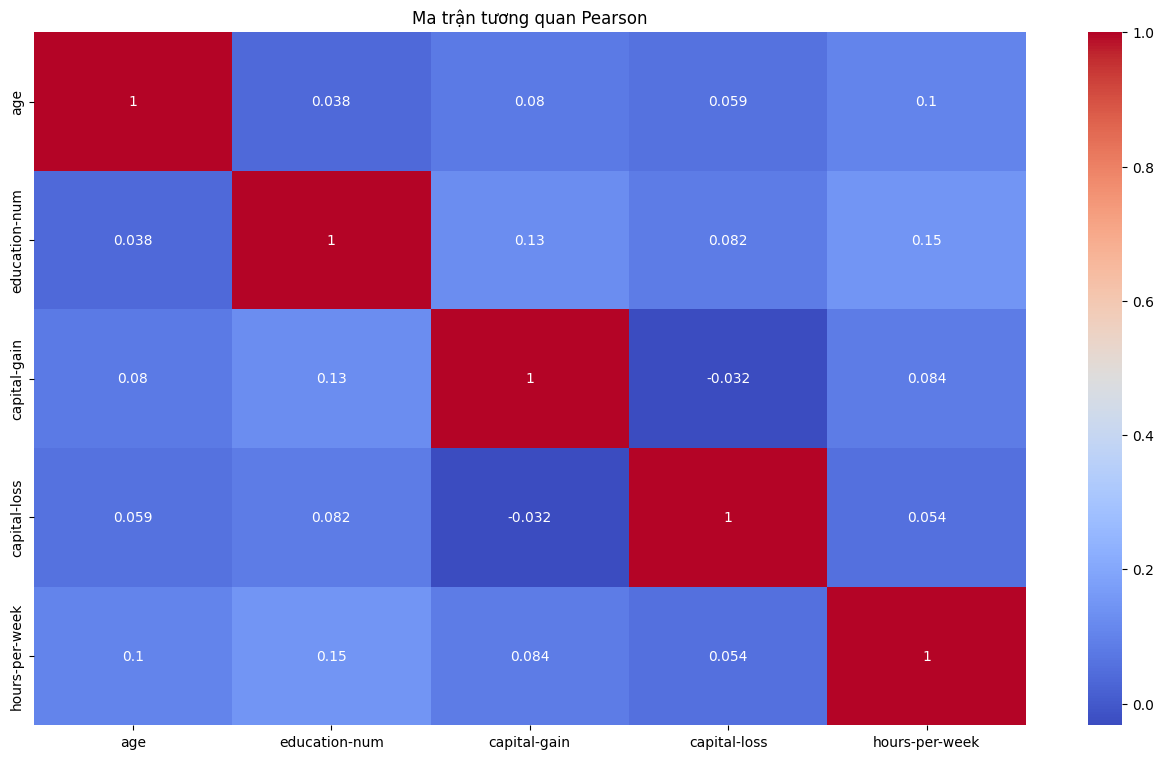


Các cột có tương quan cao muốn loại bỏ:
set()

Số cột ban đầu: 14
Số cột sau khi loại bỏ: 14


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# Lấy lại dữ liệu đã xử lý từ Câu 2
# ==============================

# data = biến bạn tạo ở Câu 2
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# ==============================
# 3. Tính Pearson
# ==============================
corr_matrix = numeric_data.corr(method='pearson')

# ==============================
# 3.1 Vẽ heatmap
# ==============================
plt.figure(figsize=(16, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
print("Nguyễn Tuấn Kiệt_6351071037")
plt.title('Ma trận tương quan Pearson')
plt.show()

# ==============================
# 3.2 Loại các cột có tương quan cao
# ==============================
threshold = 0.8
columns_to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            columns_to_drop.add(colname)

print("\nCác cột có tương quan cao muốn loại bỏ:")
print(columns_to_drop)

data_filtered = data.drop(columns=list(columns_to_drop))

print("\nSố cột ban đầu:", data.shape[1])
print("Số cột sau khi loại bỏ:", data_filtered.shape[1])


Câu 4

In [24]:
# Tách thuộc tính (features) và nhãn quyết định (label)
print("Nguyễn Tuấn Kiệt_6351071037")
features = data.drop('income', axis=1)
labels = data['income']
print("Kích thước features:", features.shape)
print("Kích thước labels:", labels.shape)


Nguyễn Tuấn Kiệt_6351071037
Kích thước features: (45222, 13)
Kích thước labels: (45222,)


Câu 5

In [25]:
print("Nguyễn Tuấn Kiệt_6351071037")
features_onehot = pd.get_dummies(features, columns=features.select_dtypes(exclude=['int64']).columns)
features_onehot

Nguyễn Tuấn Kiệt_6351071037


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,13,2174,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,33,13,0,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,39,13,0,0,36,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,38,13,0,0,50,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,44,13,5455,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
Câu 6

In [26]:
# Số dòng của tập train sau khi làm sạch
n_train = len(train_clean)

# Tách tập features
X_train = features_onehot[:n_train]
X_test  = features_onehot[n_train:]

# Tách tập nhãn
y_train = labels[:n_train]
y_test  = labels[n_train:]
print("Nguyễn Tuấn Kiệt_6351071037")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Nguyễn Tuấn Kiệt_6351071037
X_train: (30162, 103)
X_test: (15060, 103)
y_train: (30162,)
y_test: (15060,)


Câu 7

In [27]:
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 7. Huấn luyện cây ID3 (entropy)
# =============================
clf = tree.DecisionTreeClassifier(criterion="entropy", random_state=0)

clf.fit(X_train, y_train)
print("Nguyễn Tuấn Kiệt_6351071037")
print(">>> Huấn luyện xong cây ID3!")
print(clf)


Nguyễn Tuấn Kiệt_6351071037
>>> Huấn luyện xong cây ID3!
DecisionTreeClassifier(criterion='entropy', random_state=0)


In [28]:
# Dự đoán nhãn
tree_pred = clf.predict(X_test)
# Dự đoán nhãn
tree_pred = clf.predict(X_test)


In [29]:
# Dự đoán nhãn
tree_pred = clf.predict(X_test)


In [30]:
tree_score = metrics.accuracy_score(y_test, tree_pred)
print("Nguyễn Tuấn Kiệt_6351071037")

print("Accuracy:", tree_score)
print("\nReport:\n", metrics.classification_report(y_test, tree_pred))


Nguyễn Tuấn Kiệt_6351071037
Accuracy: 0.8175298804780876

Report:
               precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88     11360
        >50K       0.63      0.62      0.62      3700

    accuracy                           0.82     15060
   macro avg       0.75      0.75      0.75     15060
weighted avg       0.82      0.82      0.82     15060



In [31]:
tree_cm = metrics.confusion_matrix(y_test, tree_pred)
print(tree_cm)
print("Nguyễn Tuấn Kiệt_6351071037")


[[10031  1329]
 [ 1419  2281]]
Nguyễn Tuấn Kiệt_6351071037


Nguyễn Tuấn Kiệt_6351071037


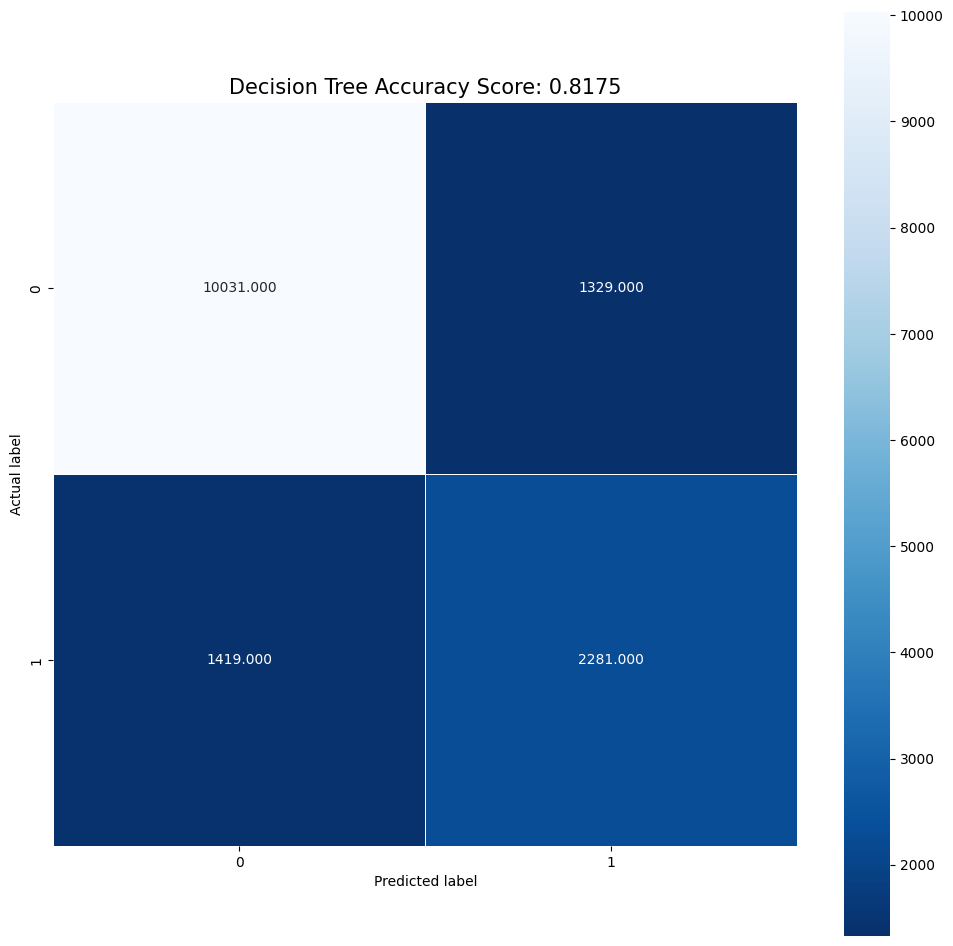

In [32]:
plt.figure(figsize=(12, 12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=.5,
            square=True, cmap='Blues_r')

plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Decision Tree Accuracy Score: {:.4f}'.format(tree_score), size=15)
print("Nguyễn Tuấn Kiệt_6351071037")
plt.show()



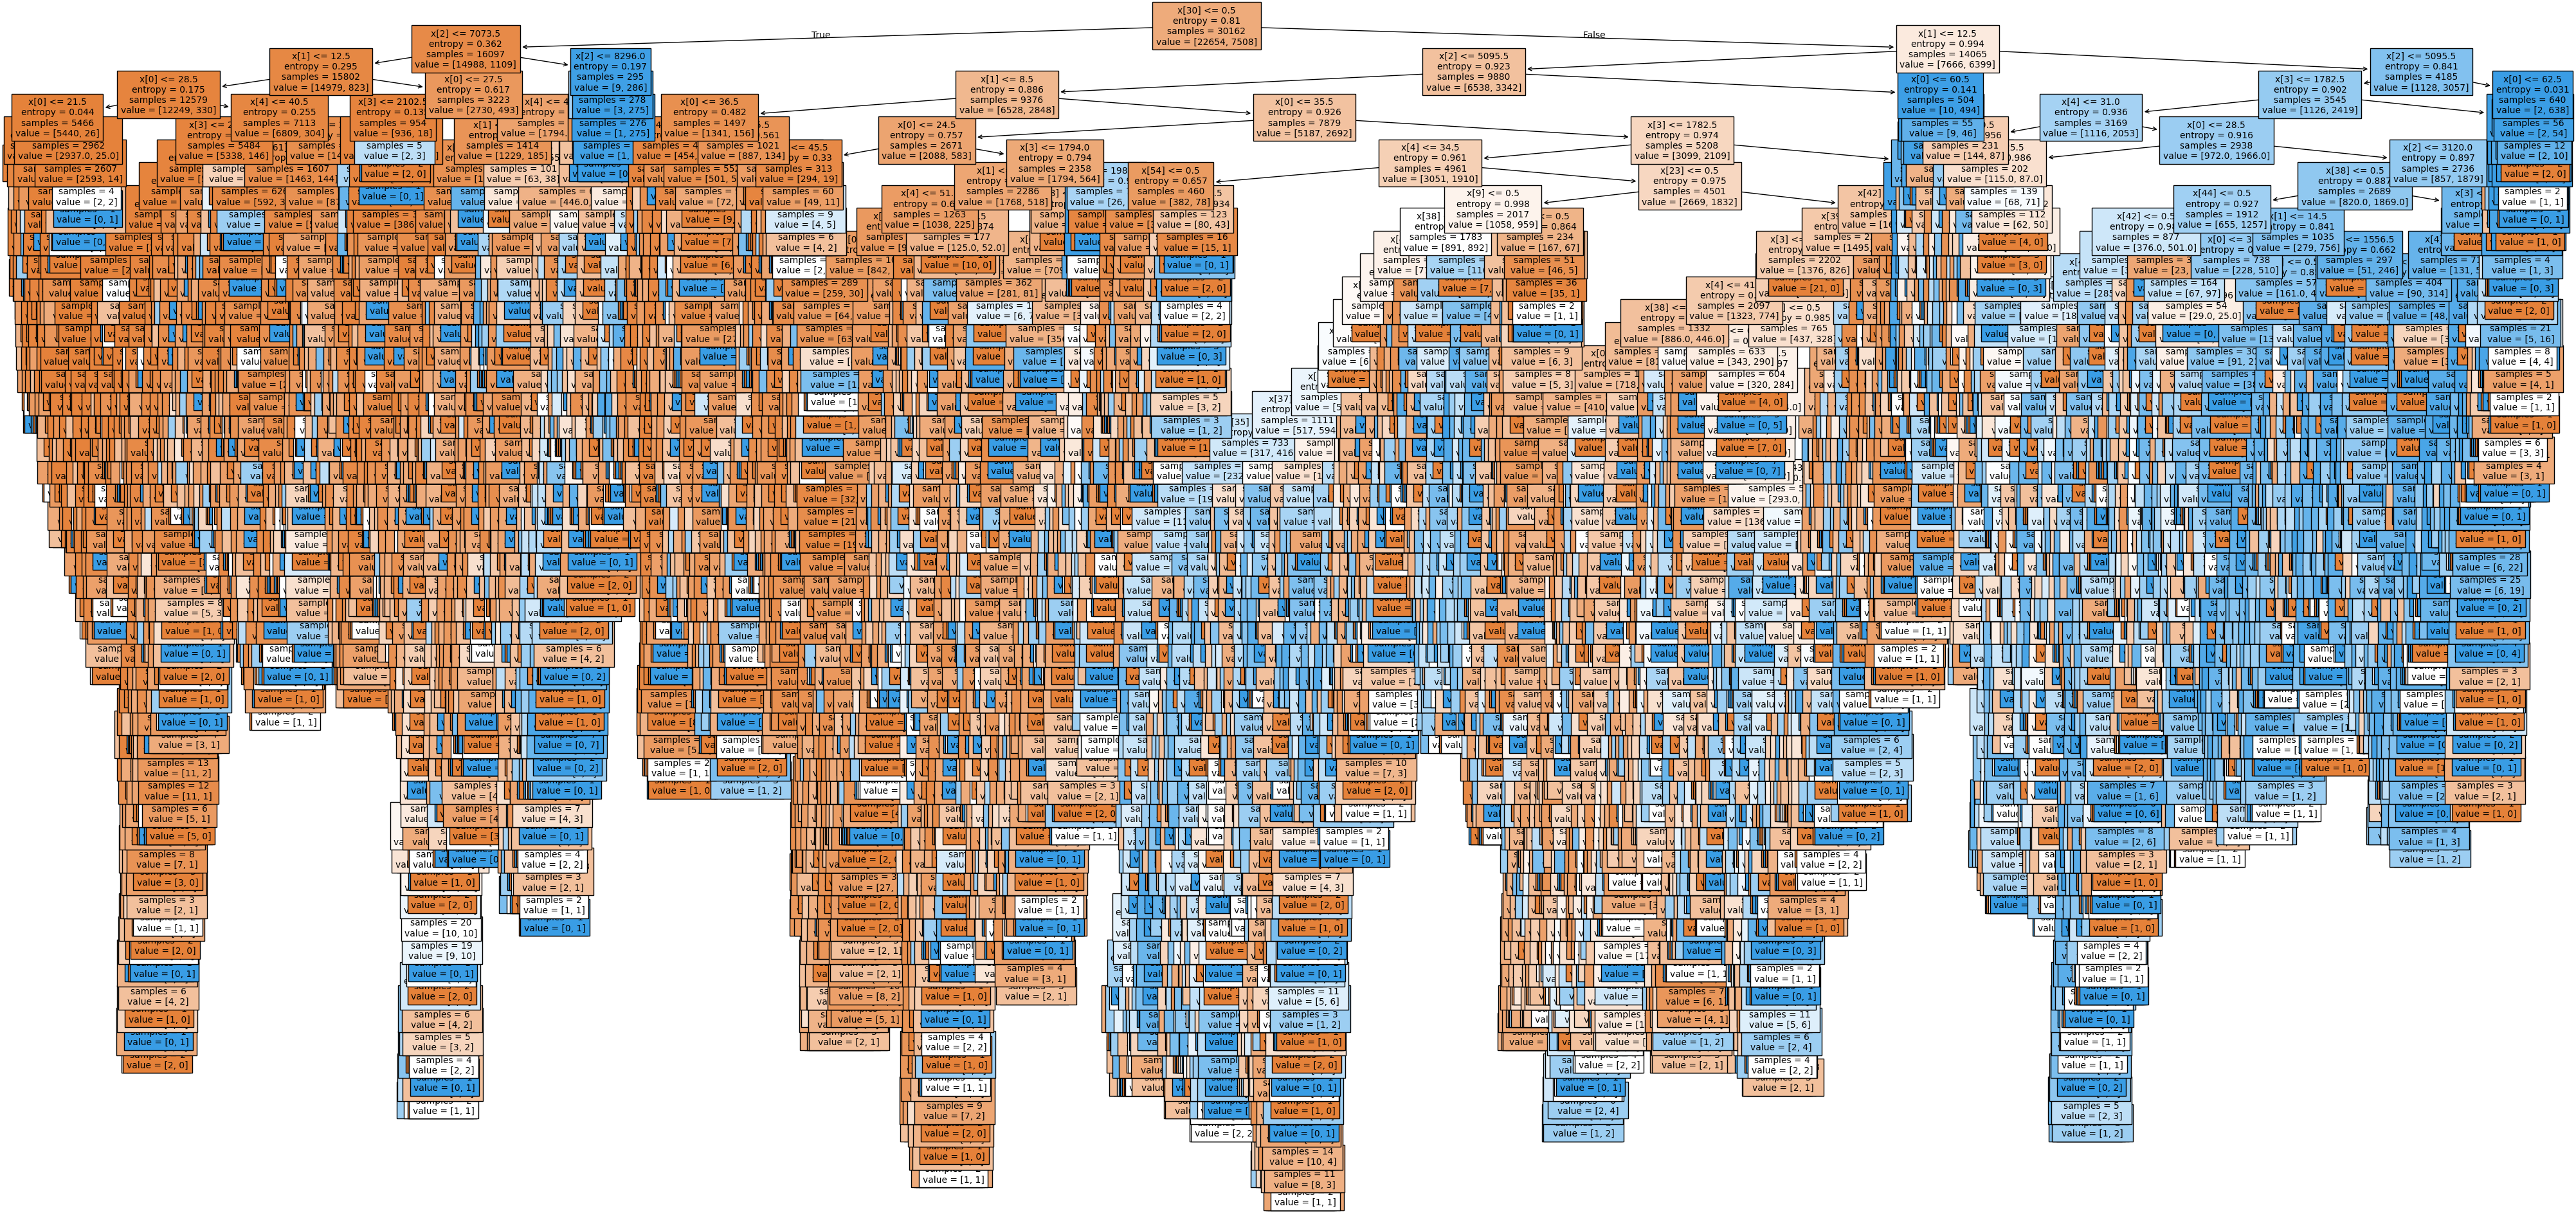

Nguyễn Tuấn Kiệt_6351071037


In [34]:
fig, ax = plt.subplots(figsize=(50, 24))
tree.plot_tree(clf, filled=True, fontsize=10)
plt.savefig('decision_tree.png', dpi=10)
plt.show()
print("Nguyễn Tuấn Kiệt_6351071037")


Câu 8

In [36]:
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 7. Huấn luyện cây ID3 (entropy)
# =============================
from sklearn.tree import DecisionTreeClassifier
# Khởi tạo mô hình Cây Quyết định với tiêu chí 'gini'
clf = DecisionTreeClassifier(criterion="gini", random_state=0)

clf.fit(X_train, y_train)
print("Nguyễn Tuấn Kiệt_6351071037")
print(">>> Huấn luyện xong cây ID3!")
print(clf)


Nguyễn Tuấn Kiệt_6351071037
>>> Huấn luyện xong cây ID3!
DecisionTreeClassifier(random_state=0)


In [37]:
# Dự đoán nhãn
tree_pred = clf.predict(X_test)
# Dự đoán nhãn
tree_pred = clf.predict(X_test)


In [38]:
# Dự đoán nhãn
tree_pred = clf.predict(X_test)


In [39]:
tree_score = metrics.accuracy_score(y_test, tree_pred)
print("Nguyễn Tuấn Kiệt_6351071037")

print("Accuracy:", tree_score)
print("\nReport:\n", metrics.classification_report(y_test, tree_pred))


Nguyễn Tuấn Kiệt_6351071037
Accuracy: 0.8122841965471448

Report:
               precision    recall  f1-score   support

       <=50K       0.87      0.88      0.88     11360
        >50K       0.62      0.60      0.61      3700

    accuracy                           0.81     15060
   macro avg       0.75      0.74      0.74     15060
weighted avg       0.81      0.81      0.81     15060



In [40]:
tree_cm = metrics.confusion_matrix(y_test, tree_pred)
print(tree_cm)
print("Nguyễn Tuấn Kiệt_6351071037")


[[10009  1351]
 [ 1476  2224]]
Nguyễn Tuấn Kiệt_6351071037


Nguyễn Tuấn Kiệt_6351071037


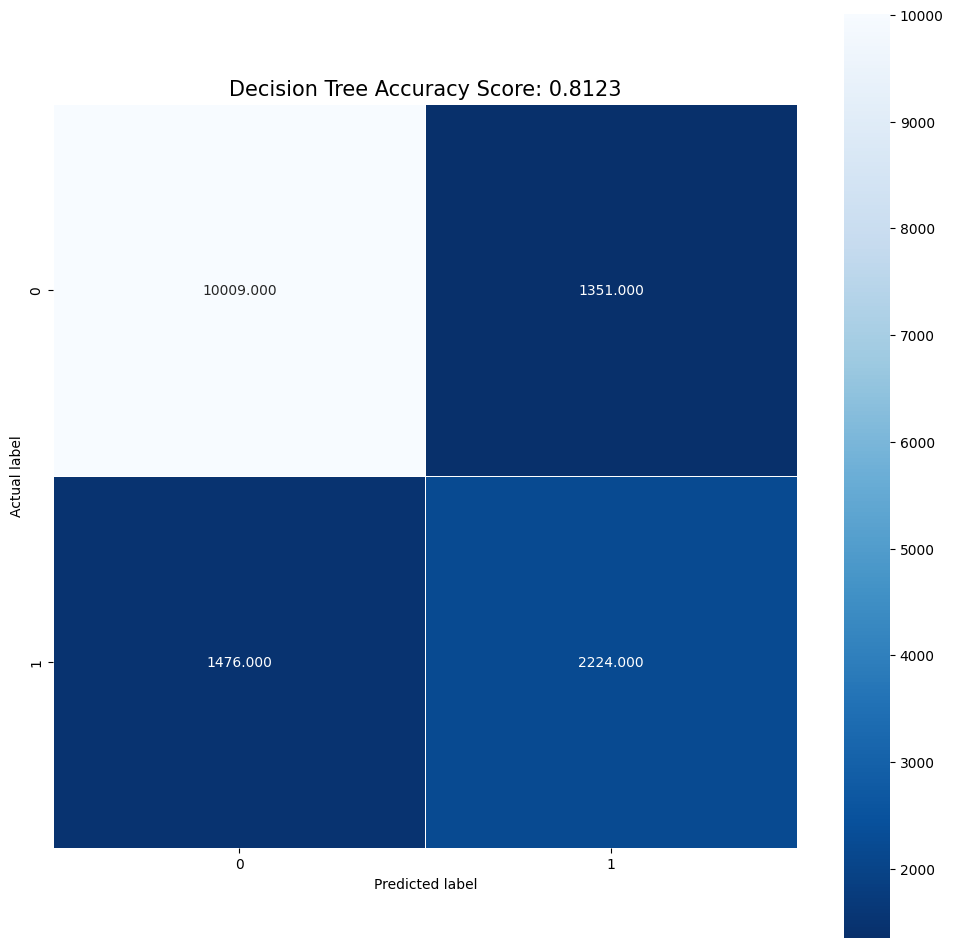

In [41]:
plt.figure(figsize=(12, 12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=.5,
            square=True, cmap='Blues_r')

plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Decision Tree Accuracy Score: {:.4f}'.format(tree_score), size=15)
print("Nguyễn Tuấn Kiệt_6351071037")
plt.show()



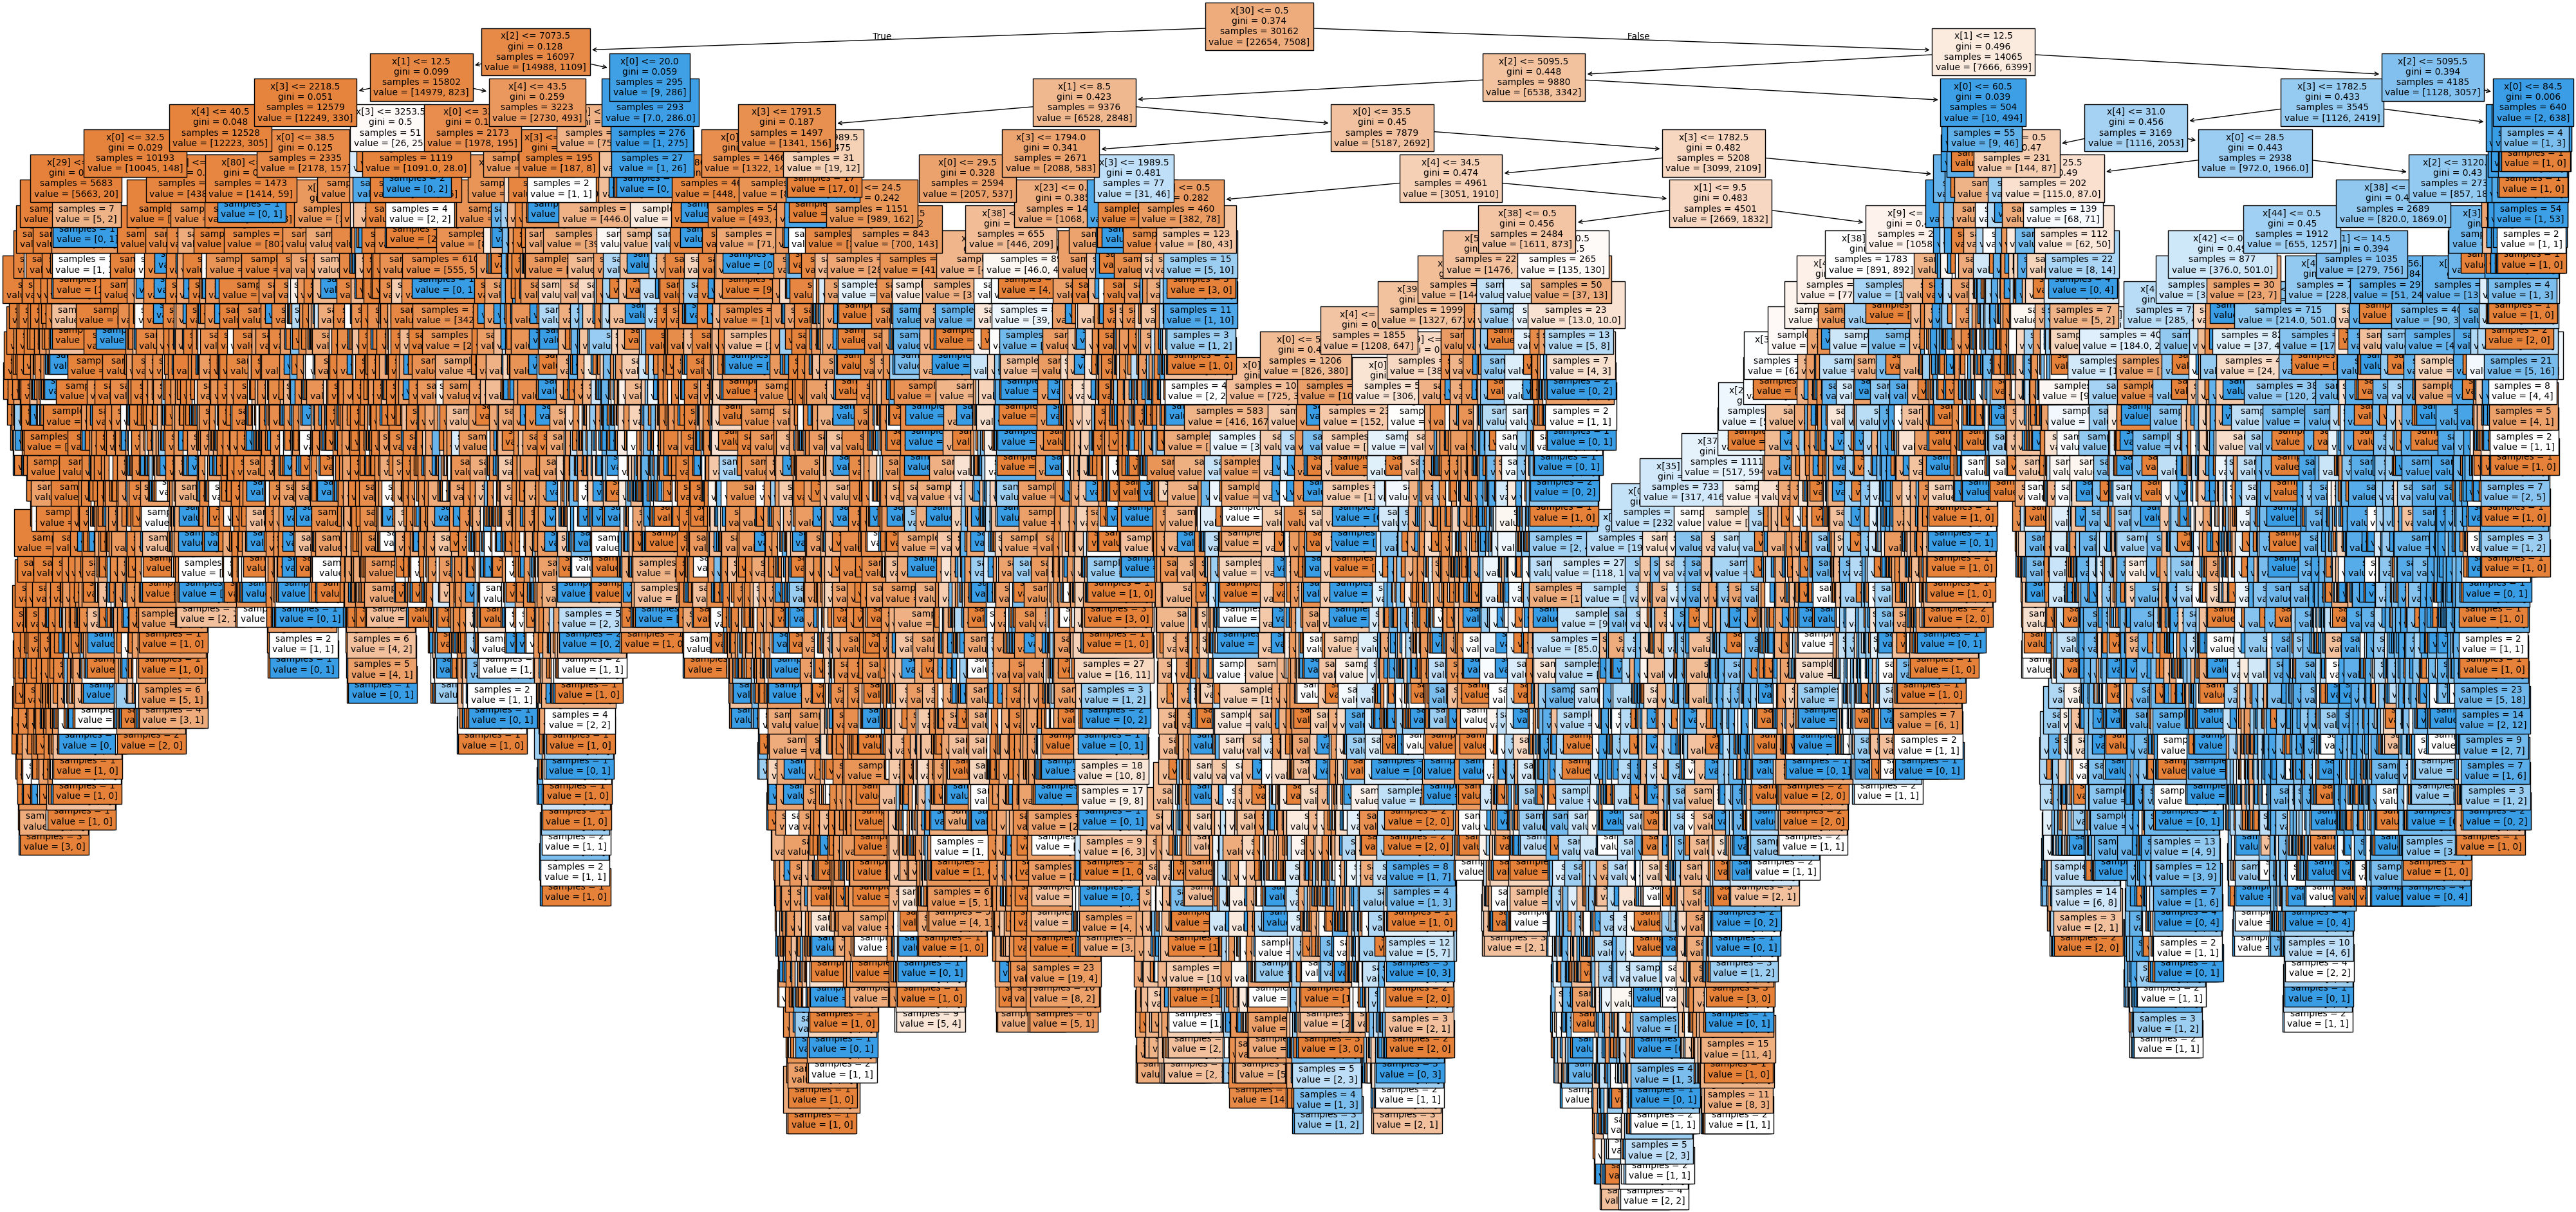

Nguyễn Tuấn Kiệt_6351071037


In [42]:
fig, ax = plt.subplots(figsize=(50, 24))
tree.plot_tree(clf, filled=True, fontsize=10)
plt.savefig('decision_tree.png', dpi=10)
plt.show()
print("Nguyễn Tuấn Kiệt_6351071037")


Câu 9

Nguyễn Tuấn Kiệt_6351071037
Accuracy: 0.8029216467463479
Report:
              precision    recall  f1-score   support

       <=50K       0.93      0.80      0.86     11360
        >50K       0.57      0.82      0.67      3700

    accuracy                           0.80     15060
   macro avg       0.75      0.81      0.76     15060
weighted avg       0.84      0.80      0.81     15060



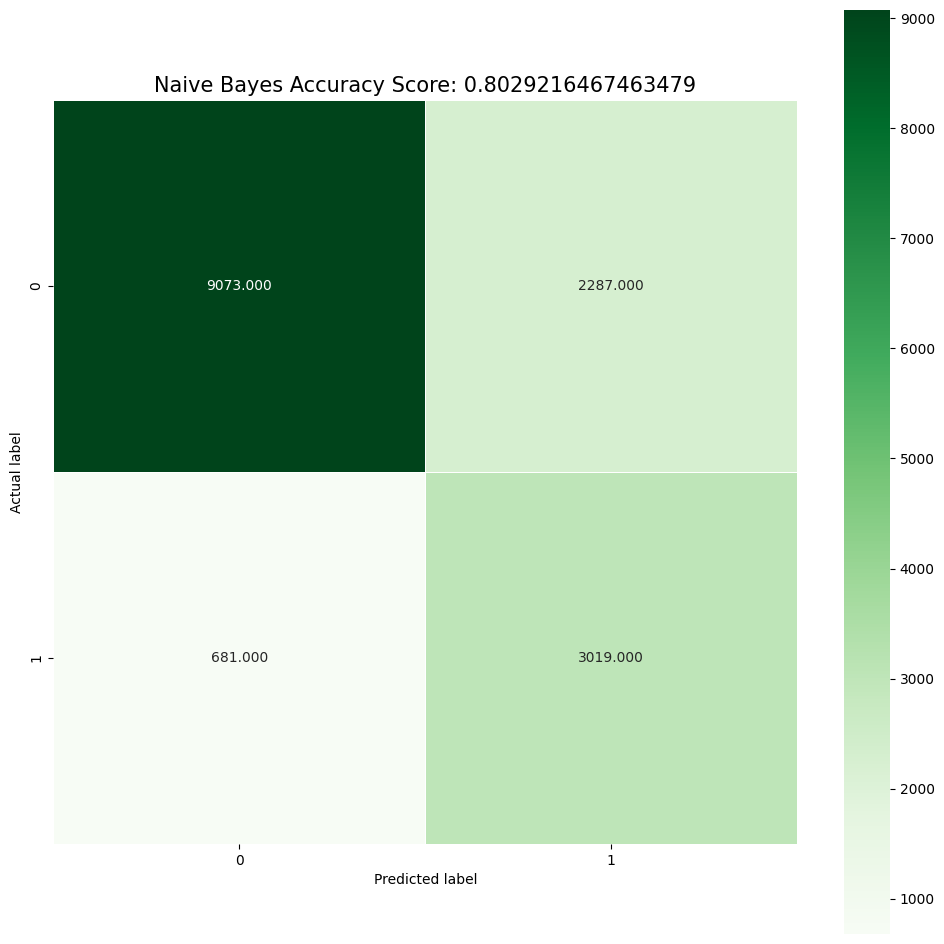

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

gnb = GaussianNB()

bayes_pred = gnb.fit(X_train, y_train).predict(X_test)


print("Nguyễn Tuấn Kiệt_6351071037")

bayes_score = metrics.accuracy_score(y_test, bayes_pred)
print("Accuracy:", bayes_score)

print("Report:")
print(metrics.classification_report(y_test, bayes_pred))

bayes_cm = metrics.confusion_matrix(y_test, bayes_pred)

plt.figure(figsize=(12, 12))
sns.heatmap(
    bayes_cm, annot=True, fmt=".3f",
    linewidths=.5, square=True, cmap='Greens'
)

plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = "Naive Bayes Accuracy Score: {0}".format(bayes_score)
plt.title(title, size=15)
plt.show()


Nguyễn Tuấn Kiệt_6351071037
 MÔ HÌNH: ID3 (Entropy)
Accuracy: 0.8155378486055777
              precision    recall  f1-score   support

       <=50K       0.87      0.88      0.88     11360
        >50K       0.63      0.61      0.62      3700

    accuracy                           0.82     15060
   macro avg       0.75      0.75      0.75     15060
weighted avg       0.81      0.82      0.81     15060

 MÔ HÌNH: CART (Gini)
Accuracy: 0.8123505976095617
              precision    recall  f1-score   support

       <=50K       0.87      0.88      0.88     11360
        >50K       0.62      0.60      0.61      3700

    accuracy                           0.81     15060
   macro avg       0.75      0.74      0.74     15060
weighted avg       0.81      0.81      0.81     15060

 MÔ HÌNH: Naive Bayes
Accuracy: 0.8029216467463479
              precision    recall  f1-score   support

       <=50K       0.93      0.80      0.86     11360
        >50K       0.57      0.82      0.67      3700


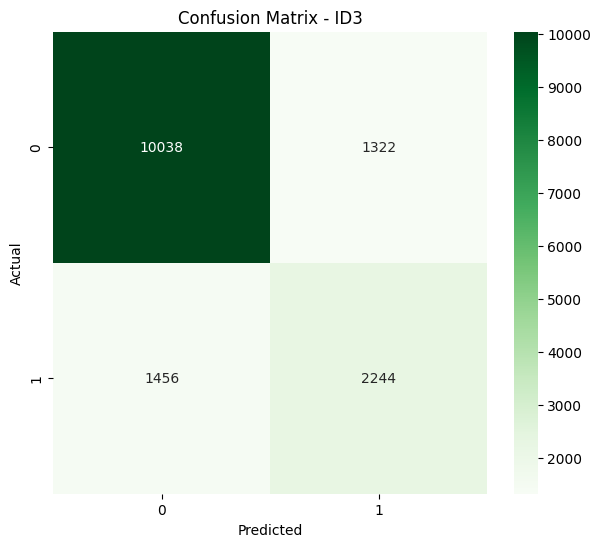

Nguyễn Tuấn Kiệt_6351071037


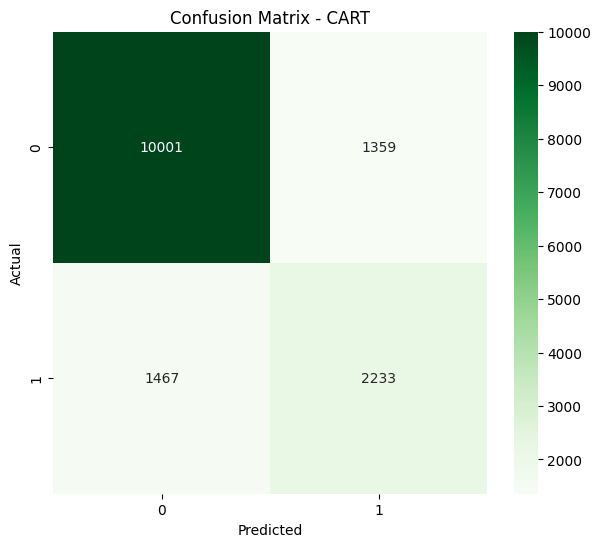

Nguyễn Tuấn Kiệt_6351071037


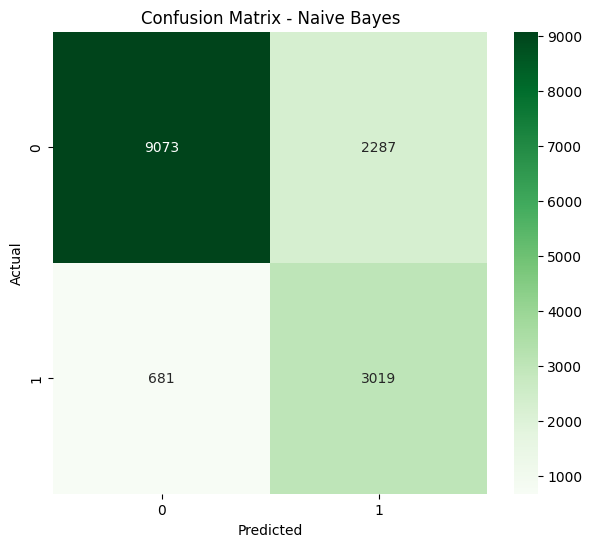

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
#  1. Train các mô hình
# ===============================

# ID3  (entropy)
from sklearn.tree import DecisionTreeClassifier
id3 = DecisionTreeClassifier(criterion='entropy')
id3.fit(X_train, y_train)
id3_pred = id3.predict(X_test)

# CART (gini)
cart = DecisionTreeClassifier(criterion='gini')
cart.fit(X_train, y_train)
cart_pred = cart.predict(X_test)

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)


# ===============================
#  2. Tính các độ đo đánh giá
# ===============================
print("Nguyễn Tuấn Kiệt_6351071037")

def evaluate_model(name, y_true, y_pred):
    print("==============================================")
    print(f" MÔ HÌNH: {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))


evaluate_model("ID3 (Entropy)", y_test, id3_pred)
evaluate_model("CART (Gini)", y_test, cart_pred)
evaluate_model("Naive Bayes", y_test, nb_pred)


# ===============================
#  3. Vẽ Confusion Matrix
# ===============================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
print("Nguyễn Tuấn Kiệt_6351071037")
plot_cm(y_test, id3_pred, "Confusion Matrix - ID3")
print("Nguyễn Tuấn Kiệt_6351071037")
plot_cm(y_test, cart_pred, "Confusion Matrix - CART")
print("Nguyễn Tuấn Kiệt_6351071037")
plot_cm(y_test, nb_pred, "Confusion Matrix - Naive Bayes")
